# Intrinsic vs. Embedding Dimensionality

A central question in neural signal analysis is: **how many independent degrees of freedom generate the observed signal?**

Two fundamentally different approaches give different — and differently useful — answers:

| Approach | Measures | Method | Mechanistic insight? |
|----------|----------|--------|---------------------|
| **Embedding dimensionality** | Variance components needed to represent the signal | PCA on windowed time series | ✗ Captures variance, not dynamics |
| **Intrinsic dimensionality** | Number of oscillatory modes generating the signal | Delay embedding → AR root analysis | ✓ Maps directly to oscillatory generators |

This tutorial demonstrates the distinction using synthetic LFP signals with **known ground truth**.  We show that PCA embedding dimensionality can mislead — especially with $1/f$ noise and nonstationarity — while intrinsic dimensionality via delay embedding reveals the true dynamical structure and provides mechanistic insight into the generating process.

In [13]:
import sys, pathlib
# Ensure the project root is on the path (works regardless of kernel)
_root = str(pathlib.Path.cwd().parents[1])  # docs/tutorials/../../
if _root not in sys.path:
    sys.path.insert(0, _root)

import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from scipy.signal import welch
from sklearn.decomposition import PCA

from NeuralFieldManifold.embedders import embed
from NeuralFieldManifold.generators import colored_noise, sinusoid
from NeuralFieldManifold.models import AR
from NeuralFieldManifold.pub_utils import set_pub_style, prettify, color_main, color_alt

set_pub_style()

# Extended palette (consistent with simulations.ipynb / model.ipynb)
c_dark   = color_main       # "black"
c_accent = color_alt         # "darkred"
c_gray   = "dimgray"
c_light  = "#d9d9d9"

## 1. Synthetic LFP with Controlled Oscillatory Content

We construct stationary AR processes where the number of oscillatory modes $K$ is exactly controlled. Each mode $(f_k, r_k)$ contributes a pair of complex conjugate poles to the AR characteristic polynomial, producing a spectral peak at frequency $f_k$ with sharpness governed by the pole radius $r_k$.

$$x(t) = \sum_{k=1}^{2K} a_k \, x(t{-}k) \;+\; \varepsilon(t), \qquad \varepsilon(t) \sim \mathcal{N}(0, \sigma^2)$$

Three signals are generated with increasing oscillatory complexity:
- **K = 1** — single alpha-band oscillation (10 Hz)
- **K = 2** — alpha + low-gamma (10, 30 Hz)
- **K = 3** — theta + beta + gamma (8, 20, 45 Hz)

In [14]:
# ── Helper functions ──────────────────────────────────────────

def ar_coeffs_from_modes(freqs, radii, fs=1000.0):
    """Build AR(2K) coefficients from K oscillatory modes.

    Each (freq, radius) pair produces one pair of complex conjugate
    poles in the characteristic polynomial.
    """
    poly = np.array([1.0])
    for f, r in zip(freqs, radii):
        theta = 2 * np.pi * f / fs
        quad = np.array([1.0, -2 * r * np.cos(theta), r**2])
        poly = np.convolve(poly, quad)
    return -poly[1:]


def simulate_ar(coeffs, T, noise_std=1.0, seed=42):
    """Simulate a stationary AR(p) process driven by white noise."""
    rng = np.random.default_rng(seed)
    p = len(coeffs)
    x = np.zeros(T, dtype=np.float64)
    eps = rng.normal(0, noise_std, T)
    for t in range(p, T):
        x[t] = coeffs @ x[t - p : t][::-1] + eps[t]
    return x.astype(np.float32)


def hankel_matrix(x, L):
    """Sliding-window (Hankel) matrix of shape (N-L+1, L)."""
    N = len(x) - L + 1
    idx = np.arange(L)[None, :] + np.arange(N)[:, None]
    return x[idx]


def pca_dim_estimate(X, threshold=0.95):
    """Number of PCs explaining >= threshold fraction of total variance."""
    pca = PCA().fit(X)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    return int(np.searchsorted(cumvar, threshold) + 1), cumvar


def participation_ratio(X):
    """Participation ratio: continuous dimensionality estimator.  PR = (Σλ)² / Σλ²."""
    lam = PCA().fit(X).explained_variance_
    return (lam.sum() ** 2) / (lam ** 2).sum()


def simulate_tvar(a_time, noise_std=0.3, seed=42, burn_in=500):
    """Simulate a time-varying AR process with burn-in."""
    rng = np.random.default_rng(seed)
    T, p = a_time.shape
    T_full = T + burn_in
    x = np.zeros(T_full, dtype=np.float64)
    eps = rng.normal(0, noise_std, T_full)
    x[:p] = eps[:p]
    for t in range(p, T_full):
        idx = t - burn_in
        a_t = a_time[max(0, min(idx, T - 1))]
        x[t] = a_t @ x[t - p : t][::-1] + eps[t]
    return x[burn_in:].astype(np.float32)

/var/folders/zl/dq7c13p16bsb4qhmx8fvgp2m0000gn/T/ipykernel_74197/3016928409.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


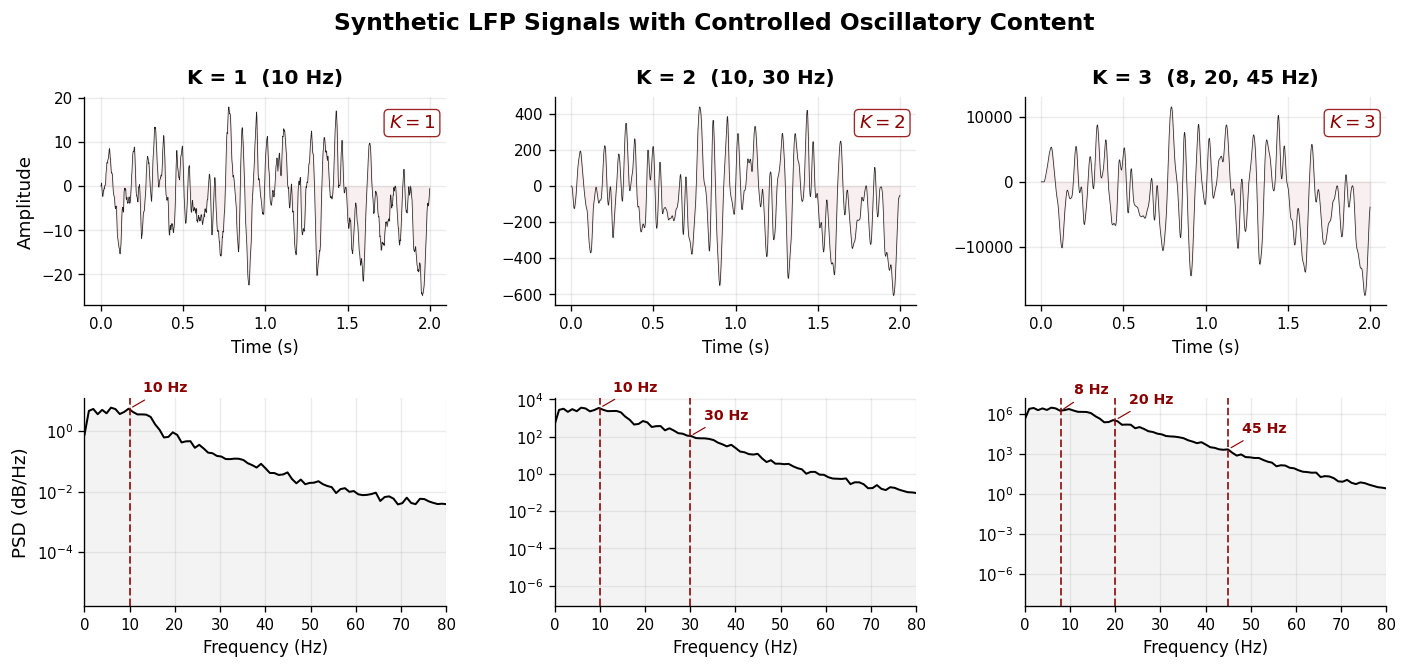

In [15]:
# ── Generate three synthetic LFP signals ─────────────────────
fs = 1000.0          # sampling rate (Hz)
T  = 10_000          # 10 seconds
L  = 100             # Hankel window length (100 ms)
m, tau = 6, 15       # delay-embedding parameters

mode_configs = [
    ("K = 1  (10 Hz)",        [10.0],             [0.95]),
    ("K = 2  (10, 30 Hz)",    [10.0, 30.0],       [0.95, 0.90]),
    ("K = 3  (8, 20, 45 Hz)", [8.0, 20.0, 45.0],  [0.95, 0.92, 0.88]),
]

signals = []
for label, freqs, radii in mode_configs:
    c = ar_coeffs_from_modes(freqs, radii, fs)
    x = simulate_ar(c, T, noise_std=0.3, seed=42)
    signals.append(dict(label=label, x=x, coeffs=c, freqs=freqs, radii=radii))

# ── Figure 1: Time series & power spectra ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 5.5),
                         gridspec_kw={"hspace": 0.45, "wspace": 0.30})
t_sec = np.arange(T) / fs

for col, s in enumerate(signals):
    K = len(s["freqs"])

    # ─ Top row: waveform (first 2 s) ─
    ax = axes[0, col]
    ax.plot(t_sec[:2000], s["x"][:2000], color=c_dark, lw=0.45, alpha=0.85)
    ax.fill_between(t_sec[:2000], s["x"][:2000], alpha=0.06, color=c_accent)
    ax.set_title(s["label"], fontsize=12, fontweight="bold", pad=8)
    if col == 0:
        ax.set_ylabel("Amplitude", fontsize=11)
    ax.set_xlabel("Time (s)", fontsize=10)
    ax.tick_params(labelsize=9)
    # annotate true K
    ax.text(0.97, 0.92, f"$K = {K}$", transform=ax.transAxes,
            ha="right", va="top", fontsize=11, fontweight="bold",
            color=c_accent,
            bbox=dict(facecolor="white", edgecolor=c_accent,
                      alpha=0.85, boxstyle="round,pad=0.25", lw=0.8))

    # ─ Bottom row: PSD ─
    f_psd, Pxx = welch(s["x"], fs=fs, nperseg=1024)
    ax = axes[1, col]
    ax.semilogy(f_psd, Pxx, color=c_dark, lw=1.2)
    ax.fill_between(f_psd, Pxx, alpha=0.08, color=c_gray)
    # mark true oscillatory frequencies
    for i, freq in enumerate(s["freqs"]):
        ax.axvline(freq, color=c_accent, ls="--", lw=1.2, alpha=0.8)
        y_peak = Pxx[np.argmin(np.abs(f_psd - freq))]
        ax.annotate(f"{freq:.0f} Hz", xy=(freq, y_peak),
                    xytext=(8, 10), textcoords="offset points",
                    fontsize=8.5, fontweight="bold", color=c_accent,
                    arrowprops=dict(arrowstyle="-", color=c_accent, lw=0.7))
    if col == 0:
        ax.set_ylabel("PSD (dB/Hz)", fontsize=11)
    ax.set_xlabel("Frequency (Hz)", fontsize=10)
    ax.set_xlim(0, 80)
    ax.tick_params(labelsize=9)

for ax in axes.flat:
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_linewidth(0.8)

plt.suptitle("Synthetic LFP Signals with Controlled Oscillatory Content",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 2. PCA Embedding Dimensionality

The standard approach to estimating "dimensionality" of a neural time series is to construct a **Hankel matrix** (sliding windows of length $L$) and apply PCA. The number of principal components needed to explain 95 % of variance is taken as the **embedding dimensionality**.

This measures how many *linear* components are needed to represent the signal's covariance structure — but it does not directly reveal the number of *dynamical modes* generating the signal. In particular:
- Each oscillatory mode contributes **two** variance directions (sine + cosine), so PCA systematically overestimates.
- Background noise adds further components, inflating the estimate.

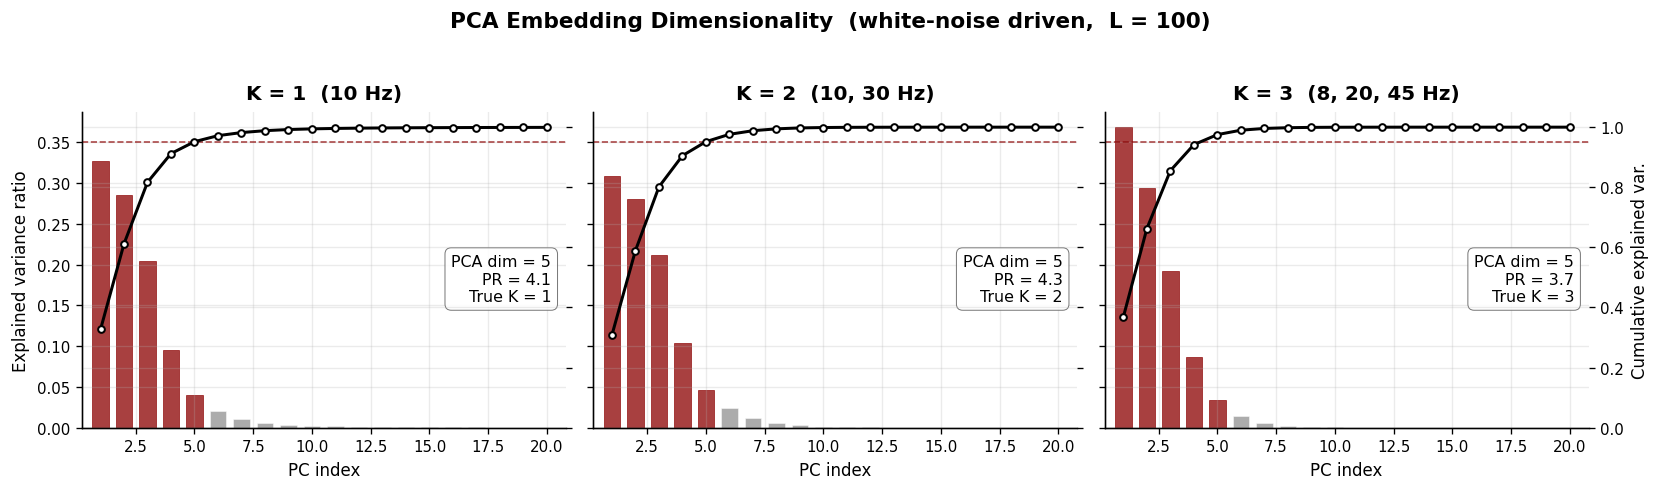

PCA embedding dimensionality (95% threshold):
  K = 1  (10 Hz)                →  True K = 1,  PCA dim = 5
  K = 2  (10, 30 Hz)            →  True K = 2,  PCA dim = 5
  K = 3  (8, 20, 45 Hz)         →  True K = 3,  PCA dim = 5


In [16]:
# ── Figure 2: PCA scree plots (clean, white-noise driven) ────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

pca_dims_clean = []
for col, s in enumerate(signals):
    K = len(s["freqs"])
    H = hankel_matrix(s["x"], L)
    d, cumvar = pca_dim_estimate(H, threshold=0.95)
    pr = participation_ratio(H)
    pca_dims_clean.append(d)

    ax = axes[col]
    # Individual variance bars
    indiv = np.diff(np.concatenate([[0], cumvar]))
    bars = ax.bar(range(1, 21), indiv[:20], color=c_gray, alpha=0.55,
                  width=0.7, edgecolor="white", linewidth=0.5, label="Individual")
    # Highlight the PCs up to the threshold
    for i in range(min(d, 20)):
        bars[i].set_color(c_accent)
        bars[i].set_alpha(0.75)

    # Cumulative curve overlay
    ax2 = ax.twinx()
    ax2.plot(range(1, 21), cumvar[:20], "-o", color=c_dark, lw=1.8, ms=4,
             markerfacecolor="white", markeredgecolor=c_dark, markeredgewidth=1.2,
             label="Cumulative", zorder=4)
    ax2.axhline(0.95, color=c_accent, ls="--", lw=1.0, alpha=0.7)
    ax2.set_ylim(0, 1.05)
    if col == 2:
        ax2.set_ylabel("Cumulative explained var.", fontsize=10)
    else:
        ax2.set_yticklabels([])
    ax2.tick_params(labelsize=9)
    for sp in ["top"]:
        ax2.spines[sp].set_visible(False)

    # Annotation box
    ax.text(0.97, 0.55, f"PCA dim = {d}\nPR = {pr:.1f}\nTrue K = {K}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9.5,
            color=c_dark,
            bbox=dict(facecolor="white", edgecolor=c_gray,
                      alpha=0.9, boxstyle="round,pad=0.4", lw=0.6))

    ax.set_title(s["label"], fontsize=12, fontweight="bold", pad=8)
    if col == 0:
        ax.set_ylabel("Explained variance ratio", fontsize=10)
    ax.set_xlabel("PC index", fontsize=10)
    ax.set_xlim(0.2, 20.8)
    ax.tick_params(labelsize=9)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

plt.suptitle("PCA Embedding Dimensionality  (white-noise driven,  L = 100)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("PCA embedding dimensionality (95% threshold):")
for s, d in zip(signals, pca_dims_clean):
    K = len(s["freqs"])
    print(f"  {s['label']:28s}  →  True K = {K},  PCA dim = {d}")

## 3. Intrinsic Dimensionality via Delay Embedding

Our approach reconstructs the **state-space manifold** of the signal using Takens delay embedding:

$$\mathbf{z}(t) = \bigl[x(t),\; x(t{-}\tau),\; \ldots,\; x(t{-}(m{-}1)\tau)\bigr]$$

The resulting trajectory lies on a low-dimensional manifold whose **topology** reflects the number of oscillatory modes:

- **K = 1** mode → 1-torus (ring / limit cycle)
- **K = 2** modes → 2-torus (donut)
- **K = 3** modes → 3-torus (nested loops)

This *intrinsic* dimensionality ($= K$) is a property of the **dynamics**, not of the variance structure.  It directly answers: *how many independent oscillatory generators produced this signal?*

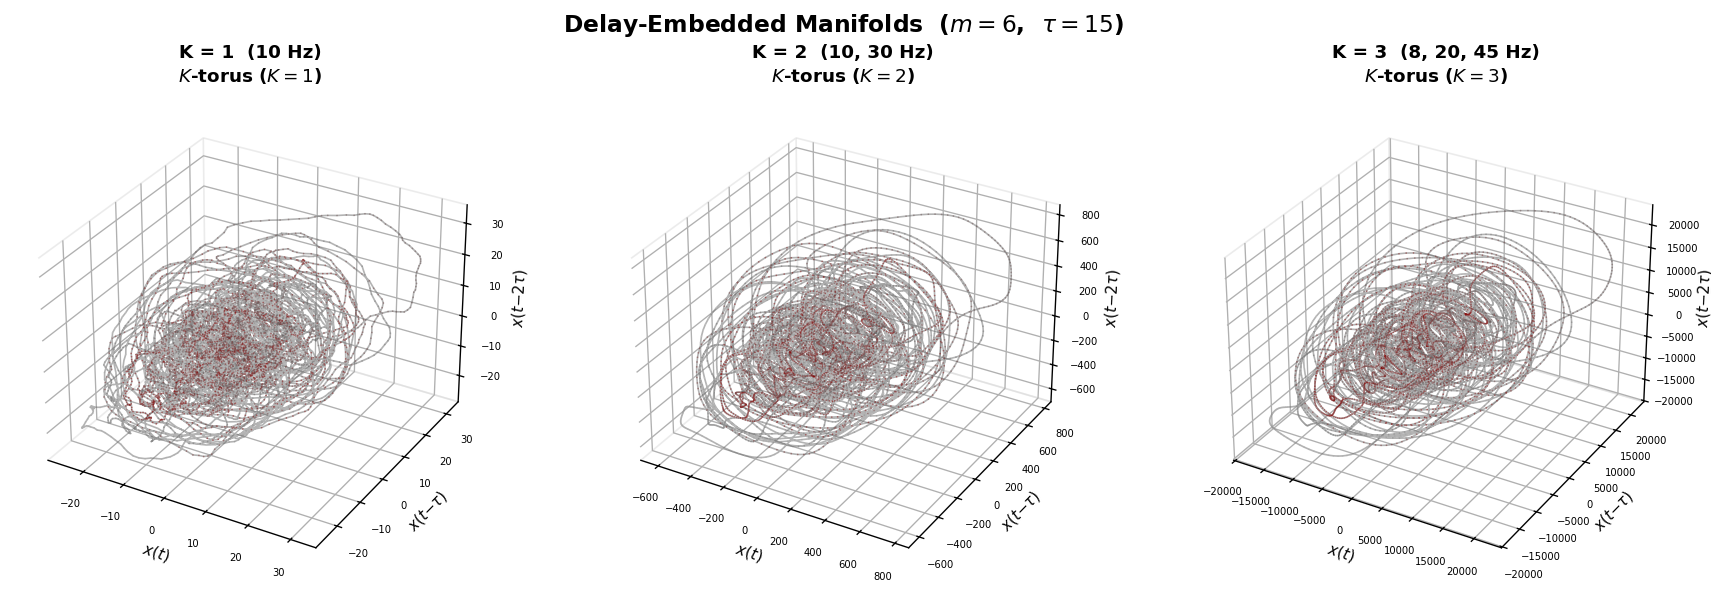

In [43]:
# ── Figure 3: Delay-embedded manifolds (color-coded by time) ─
from matplotlib.colors import LinearSegmentedColormap

fig = plt.figure(figsize=(15, 5))

cmap_traj = LinearSegmentedColormap.from_list(
    "gray_darkred", [c_light, c_gray, c_accent], N=256)

for col, s in enumerate(signals):
    K = len(s["freqs"])
    Z = np.asarray(embed(jnp.array(s["x"]), m=m, tau=tau))
    N_pts = Z.shape[0]

    ax = fig.add_subplot(1, 3, col + 1, projection="3d")

    # Continuous line for connectivity
    ax.plot(Z[:, 0], Z[:, 1], Z[:, 2],
            color=c_gray, lw=1.0, alpha=0.5, zorder=1)

    # Color-coded scatter on top (denser, larger)
    t_color = np.linspace(0, 1, N_pts)
    ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2],
               c=t_color, cmap=cmap_traj, s=1.0, alpha=0.5,
               rasterized=True, zorder=2, edgecolors="none")

    ax.set_title(f"{s['label']}\n$K$-torus ($K={K}$)",
                 fontsize=11, fontweight="bold", pad=12)
    ax.set_xlabel(r"$x(t)$", fontsize=9, labelpad=0)
    ax.set_ylabel(r"$x(t{-}\tau)$", fontsize=9, labelpad=0)
    ax.set_zlabel(r"$x(t{-}2\tau)$", fontsize=9, labelpad=0)
    ax.tick_params(labelsize=6)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor(c_light)
    ax.yaxis.pane.set_edgecolor(c_light)
    ax.zaxis.pane.set_edgecolor(c_light)
    ax.grid(alpha=0.15)

plt.suptitle(f"Delay-Embedded Manifolds  ($m = {m}$,  $\\tau = {tau}$)",
             fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

### AR Root Analysis — Recovering Oscillatory Modes

Fitting an AR model and examining the **roots of the characteristic polynomial** directly identifies individual oscillatory modes. Complex conjugate root pairs near the unit circle correspond to sustained oscillations; their angular positions give the frequencies:

$$f_k = \frac{|\arg(z_k)|}{2\pi} \cdot f_s$$

This is the core of **intrinsic dimensionality**: we recover *which* oscillatory generators produced the signal and *at what frequencies* — mechanistic insight that PCA cannot provide.

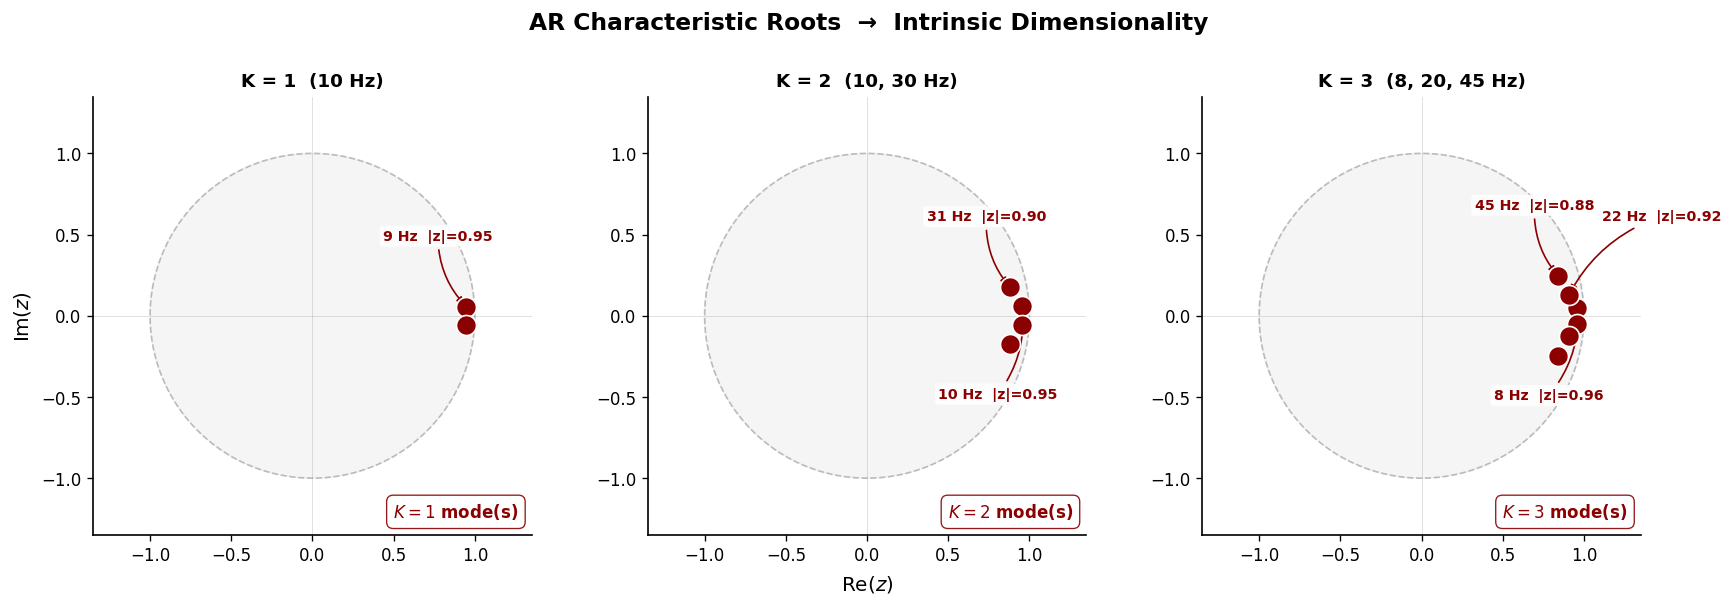

Intrinsic dimensionality (AR root analysis):
  K = 1  (10 Hz)                →  True K = 1,  recovered K = 1
  K = 2  (10, 30 Hz)            →  True K = 2,  recovered K = 2
  K = 3  (8, 20, 45 Hz)         →  True K = 3,  recovered K = 3


In [19]:
# ── Figure 4: AR roots in the complex plane ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
theta_circ = np.linspace(0, 2 * np.pi, 200)

ar_modes_clean = []
for col, s in enumerate(signals):
    p_order = len(s["coeffs"])
    X_lag, y_lag = AR.lag_matrix(s["x"], p_order)
    w = AR.fit(X_lag, y_lag)
    phi = w[1:]

    ar_poly = np.concatenate([[1.0], -phi])
    roots = np.roots(ar_poly)

    osc = roots[(np.abs(roots.imag) > 1e-6) & (roots.imag > 0)]
    ar_modes_clean.append(len(osc))

    ax = axes[col]

    # Shaded stable region
    ax.fill(np.cos(theta_circ), np.sin(theta_circ),
            color=c_light, alpha=0.25, zorder=0)
    ax.plot(np.cos(theta_circ), np.sin(theta_circ),
            color=c_gray, lw=1.0, alpha=0.4, ls="--")

    # Reference lines
    ax.axhline(0, color=c_gray, lw=0.4, alpha=0.3)
    ax.axvline(0, color=c_gray, lw=0.4, alpha=0.3)

    # Real roots (non-oscillatory)
    real_mask = np.abs(roots.imag) < 1e-6
    if np.any(real_mask):
        ax.plot(roots[real_mask].real, roots[real_mask].imag,
                "s", color=c_gray, ms=7, alpha=0.5, zorder=3,
                markeredgecolor="white", markeredgewidth=0.5)

    # Complex non-oscillatory roots
    complex_mask = (~real_mask)
    osc_idx = set(np.where((np.abs(roots.imag) > 1e-6) & (roots.imag > 0))[0])
    conj_idx = set(np.where((np.abs(roots.imag) > 1e-6) & (roots.imag < 0))[0])
    non_osc = set(range(len(roots))) - osc_idx - conj_idx - set(np.where(real_mask)[0])
    if non_osc:
        idx = list(non_osc)
        ax.plot(roots[idx].real, roots[idx].imag,
                "o", color=c_gray, ms=8, alpha=0.45, zorder=3,
                markeredgecolor="white", markeredgewidth=0.5)

    # Highlighted oscillatory roots (+ conjugates)
    ax.plot(osc.real, osc.imag, "o", color=c_accent, ms=12, zorder=5,
            markeredgecolor="white", markeredgewidth=1.0)
    ax.plot(osc.real, -osc.imag, "o", color=c_accent, ms=12, zorder=5,
            markeredgecolor="white", markeredgewidth=1.0)

    # Frequency annotations with spread-out offsets
    offsets = [(-50, 40), (-50, -55), (20, 45)]  # spread for up to 3 modes
    for i, r in enumerate(osc):
        f_hz = np.abs(np.angle(r)) * fs / (2 * np.pi)
        rad = np.abs(r)
        ofs = offsets[i % len(offsets)]
        ax.annotate(
            f"{f_hz:.0f} Hz  |z|={rad:.2f}",
            xy=(r.real, r.imag),
            xytext=ofs, textcoords="offset points",
            fontsize=8.5, color=c_accent, fontweight="bold",
            arrowprops=dict(arrowstyle="-|>", color=c_accent,
                            lw=1.0, connectionstyle="arc3,rad=0.2"),
            bbox=dict(facecolor="white", edgecolor="none",
                      alpha=0.9, boxstyle="round,pad=0.25"))

    K = len(s["freqs"])
    ax.set_title(f"{s['label']}", fontsize=11, fontweight="bold")
    ax.text(0.97, 0.03, f"$K = {len(osc)}$ mode(s)",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=10, color=c_accent, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor=c_accent,
                      alpha=0.9, boxstyle="round,pad=0.4", lw=0.8))

    prettify(ax,
             xlabel="Re$(z)$" if col == 1 else None,
             ylabel="Im$(z)$" if col == 0 else None)
    ax.set_aspect("equal")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)

plt.suptitle("AR Characteristic Roots  →  Intrinsic Dimensionality",
             y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Intrinsic dimensionality (AR root analysis):")
for s, n in zip(signals, ar_modes_clean):
    K = len(s["freqs"])
    print(f"  {s['label']:28s}  →  True K = {K},  recovered K = {n}")

## 4. The $1/f$ Noise Challenge

Real neural recordings contain broadband $1/f^\alpha$ background activity. This "aperiodic" component has dramatic effects on PCA-based dimensionality estimates: it adds slowly decaying eigenvalues that **inflate** the apparent dimensionality.

By contrast, delay embedding is robust: the $1/f$ background adds **thickness** to the manifold but does not change its **topology**. The torus structure — and hence the intrinsic dimensionality — is preserved.

We demonstrate this on the K = 2 signal with additive noise of increasing spectral exponent α.

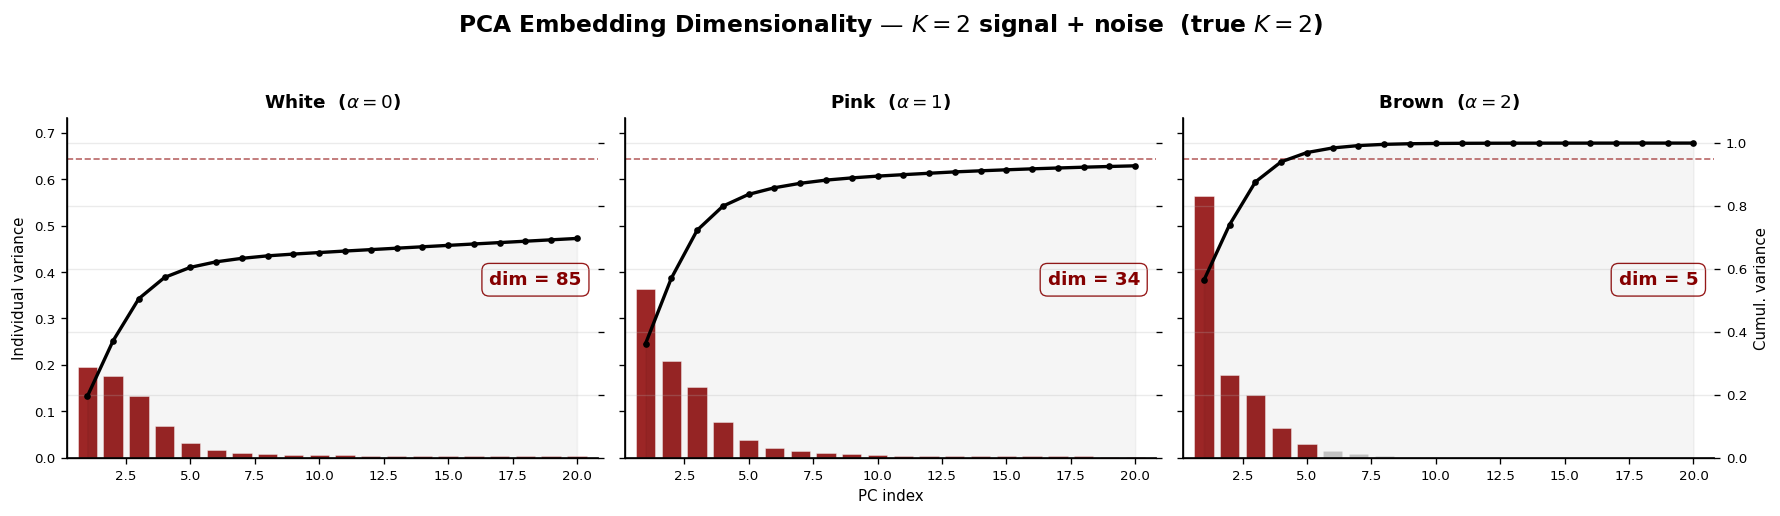

PCA dimensionality with noise (K = 2, true modes = 2):
  White  ($\alpha=0$)   →  PCA dim = 85
  Pink  ($\alpha=1$)    →  PCA dim = 34
  Brown  ($\alpha=2$)   →  PCA dim = 5


In [20]:
# ── Figure 5: PCA inflation under 1/f noise ──────────────────
base_x = signals[1]["x"]  # K = 2 signal

noise_configs = [
    ("White  ($\\alpha=0$)", 0.0),
    ("Pink  ($\\alpha=1$)",  1.0),
    ("Brown  ($\\alpha=2$)", 2.0),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

pca_dims_noise_k2 = []
for col, (nlabel, alpha) in enumerate(noise_configs):
    noise = np.asarray(colored_noise(T, alpha=alpha, seed=7))
    noise = float(np.std(base_x)) * 0.8 * noise
    x_noisy = base_x + noise

    H = hankel_matrix(x_noisy, L)
    d, cumvar = pca_dim_estimate(H, threshold=0.95)
    pca_dims_noise_k2.append(d)

    ax = axes[col]

    n_bars = 20
    indiv = np.diff(np.concatenate([[0], cumvar[:n_bars]]))
    x_idx = np.arange(1, n_bars + 1)

    # Individual variance (bars): highlight ≤ d
    colors_bar = [c_accent if i <= d else c_gray for i in x_idx]
    alphas_bar = [0.85 if i <= d else 0.35 for i in x_idx]
    for i, (xi, hi, ci, ai) in enumerate(
            zip(x_idx, indiv, colors_bar, alphas_bar)):
        ax.bar(xi, hi, width=0.75, color=ci, alpha=ai,
               edgecolor="white", linewidth=0.3)

    # Cumulative curve on twinx
    ax2 = ax.twinx()
    ax2.plot(x_idx, cumvar[:n_bars], color=color_main, lw=2.0,
             marker="o", ms=3, zorder=4)
    ax2.axhline(0.95, color=c_accent, ls="--", lw=1.0, alpha=0.6)
    ax2.fill_between(x_idx, cumvar[:n_bars], alpha=0.04, color=color_main)
    ax2.set_ylim(0, 1.08)
    ax2.tick_params(labelsize=8)
    if col < 2:
        ax2.set_yticklabels([])
    else:
        ax2.set_ylabel("Cumul. variance", fontsize=9)

    # Dimension annotation
    ax.text(0.97, 0.55, f"dim = {d}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=11, fontweight="bold", color=c_accent,
            bbox=dict(facecolor="white", edgecolor=c_accent,
                      alpha=0.9, boxstyle="round,pad=0.4", lw=0.8))

    ax.set_title(nlabel, fontsize=11, fontweight="bold")
    ax.set_xlim(0.2, n_bars + 0.8)
    ax.set_ylim(0, indiv.max() * 1.3)
    ax.tick_params(labelsize=8)
    if col == 0:
        ax.set_ylabel("Individual variance", fontsize=9)
    if col == 1:
        ax.set_xlabel("PC index", fontsize=9)
    prettify(ax)
    ax2.spines["top"].set_visible(False)

plt.suptitle("PCA Embedding Dimensionality — $K=2$ signal + noise  (true $K=2$)",
             y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("PCA dimensionality with noise (K = 2, true modes = 2):")
for (nlabel, _), d in zip(noise_configs, pca_dims_noise_k2):
    print(f"  {nlabel:20s}  →  PCA dim = {d}")

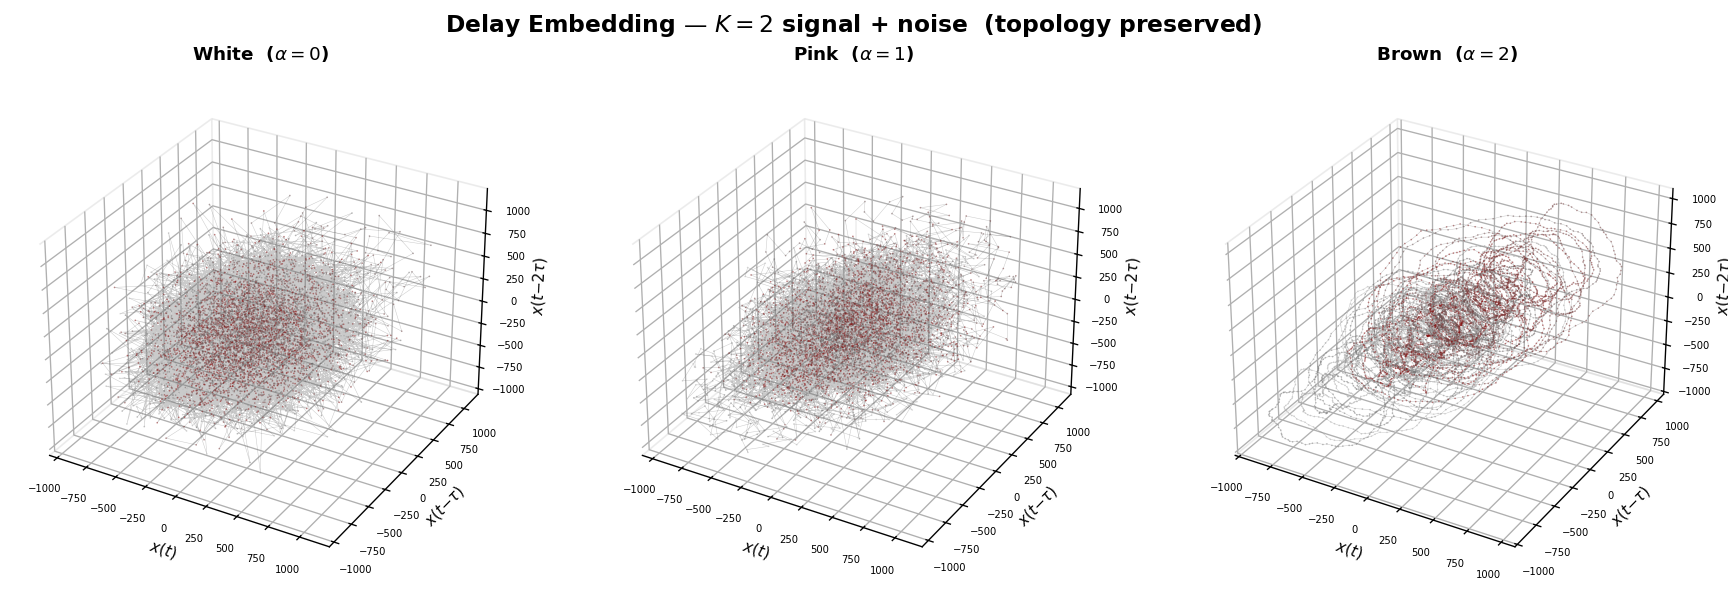

In [38]:
# ── Figure 6: Delay embedding preserves topology under noise ─
from matplotlib.colors import LinearSegmentedColormap

fig = plt.figure(figsize=(15, 5))

cmap_traj = LinearSegmentedColormap.from_list(
    "gray_darkred", [c_light, c_gray, c_accent], N=256)

for col, (nlabel, alpha) in enumerate(noise_configs):
    noise = np.asarray(colored_noise(T, alpha=alpha, seed=7))
    noise = float(np.std(base_x)) * 0.8 * noise
    x_noisy = base_x + noise

    Z = np.asarray(embed(jnp.array(x_noisy), m=m, tau=tau))
    N_pts = Z.shape[0]

    ax = fig.add_subplot(1, 3, col + 1, projection="3d")

    # Continuous line for connectivity
    ax.plot(Z[:, 0], Z[:, 1], Z[:, 2],
            color=c_gray, lw=0.3, alpha=0.35, zorder=1)

    # Color-coded scatter on top
    t_color = np.linspace(0, 1, N_pts)
    ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2],
               c=t_color, cmap=cmap_traj, s=1.0, alpha=0.5,
               rasterized=True, zorder=2, edgecolors="none")

    ax.set_title(nlabel, fontsize=11, fontweight="bold", pad=12)
    ax.set_xlabel(r"$x(t)$", fontsize=9, labelpad=0)
    ax.set_ylabel(r"$x(t{-}\tau)$", fontsize=9, labelpad=0)
    ax.set_zlabel(r"$x(t{-}2\tau)$", fontsize=9, labelpad=0)
    ax.tick_params(labelsize=6)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor(c_light)
    ax.yaxis.pane.set_edgecolor(c_light)
    ax.zaxis.pane.set_edgecolor(c_light)
    ax.grid(alpha=0.15)

plt.suptitle("Delay Embedding — $K=2$ signal + noise  (topology preserved)",
             y=0.98, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Nonstationary Dynamics: Time-Varying AR

Real LFP signals are **nonstationary** — the spectral content changes over time as brain states evolve.  PCA on the full signal's Hankel matrix conflates different time epochs, producing a blurred dimensionality estimate that reflects neither the early nor the late dynamics.

Delay embedding, by contrast, traces a *continuous trajectory* on the manifold.  As the AR coefficients evolve, the trajectory smoothly deforms, but the manifold topology is preserved as long as the number of oscillatory modes remains constant.

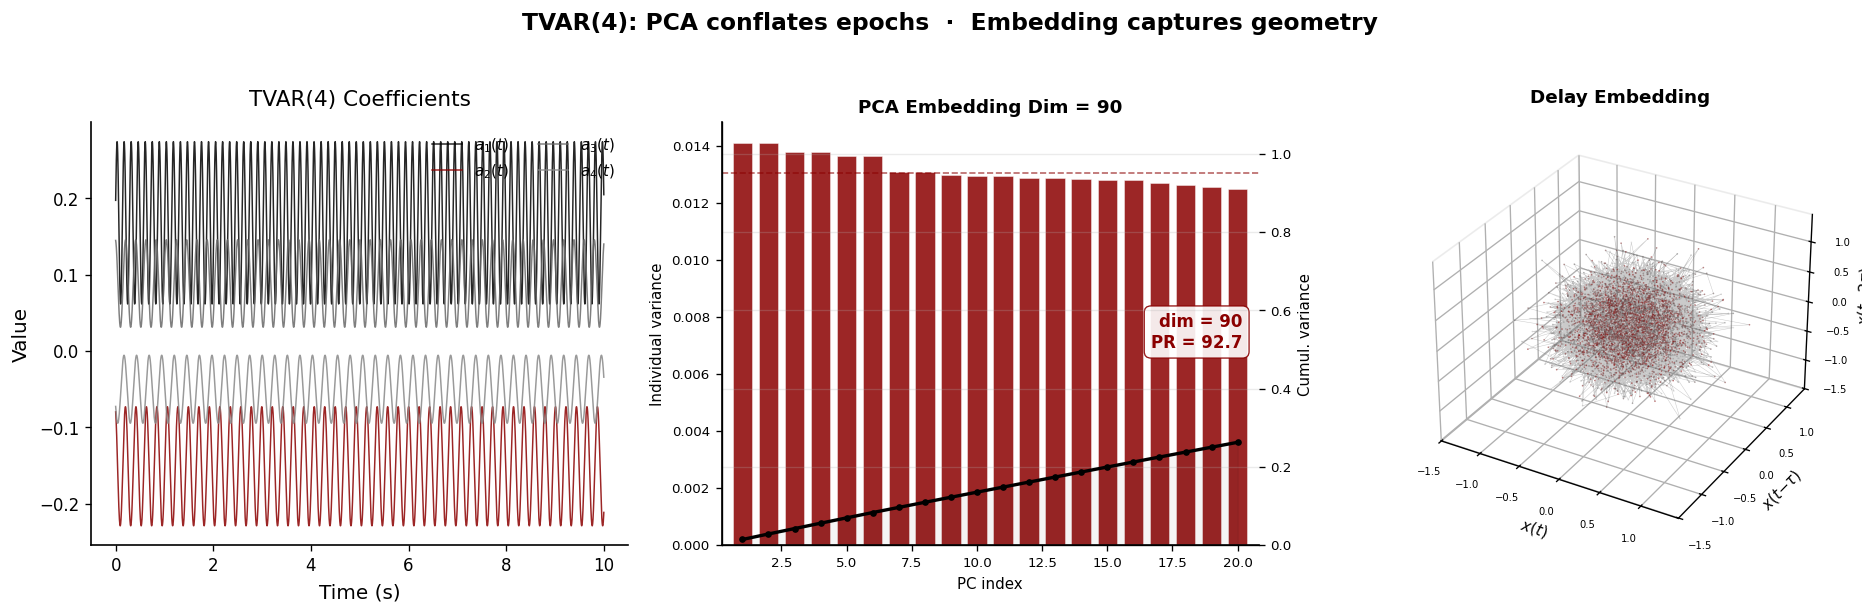

In [39]:
# ── Figure 7: TVAR — nonstationarity comparison ──────────────
rng_tvar = np.random.default_rng(0)
T_tvar = 10_000
a_time = sinusoid(T=T_tvar, p=4, rng=rng_tvar)
x_tvar = simulate_tvar(a_time, noise_std=0.3, seed=42)

fig = plt.figure(figsize=(16, 5))

# ─── Panel 1: time-varying coefficients ───
ax1 = fig.add_subplot(1, 3, 1)
coeff_colors = [color_main, c_accent, c_gray, c_light.replace("#d9d9d9", "#888888")]
for k in range(a_time.shape[1]):
    cc = [color_main, c_accent, c_gray, "#888888"][k]
    ax1.plot(np.arange(T_tvar) / fs, a_time[:, k],
             lw=0.9, color=cc, alpha=0.85,
             label=f"$a_{{{k+1}}}(t)$")
prettify(ax1, title="TVAR(4) Coefficients",
         xlabel="Time (s)", ylabel="Value", add_legend=True)
ax1.legend(frameon=False, fontsize=9, loc="upper right", ncol=2)

# ─── Panel 2: PCA scree ───
H_tvar = hankel_matrix(x_tvar, L)
d_tvar, cumvar_tvar = pca_dim_estimate(H_tvar, threshold=0.95)
pr_tvar = participation_ratio(H_tvar)

ax2 = fig.add_subplot(1, 3, 2)
n_bars = 20
indiv_tvar = np.diff(np.concatenate([[0], cumvar_tvar[:n_bars]]))
x_idx = np.arange(1, n_bars + 1)
colors_bar = [c_accent if i <= d_tvar else c_gray for i in x_idx]
alphas_bar = [0.85 if i <= d_tvar else 0.35 for i in x_idx]
for i, (xi, hi, ci, ai) in enumerate(
        zip(x_idx, indiv_tvar, colors_bar, alphas_bar)):
    ax2.bar(xi, hi, width=0.75, color=ci, alpha=ai,
            edgecolor="white", linewidth=0.3)

ax2b = ax2.twinx()
ax2b.plot(x_idx, cumvar_tvar[:n_bars], color=color_main, lw=2.0,
          marker="o", ms=3, zorder=4)
ax2b.axhline(0.95, color=c_accent, ls="--", lw=1.0, alpha=0.6)
ax2b.fill_between(x_idx, cumvar_tvar[:n_bars], alpha=0.04, color=color_main)
ax2b.set_ylim(0, 1.08)
ax2b.set_ylabel("Cumul. variance", fontsize=9)
ax2b.tick_params(labelsize=8)

ax2.text(0.97, 0.55, f"dim = {d_tvar}\nPR = {pr_tvar:.1f}",
         transform=ax2.transAxes, ha="right", va="top",
         fontsize=10, fontweight="bold", color=c_accent,
         bbox=dict(facecolor="white", edgecolor=c_accent,
                   alpha=0.9, boxstyle="round,pad=0.4", lw=0.8))

ax2.set_title(f"PCA Embedding Dim = {d_tvar}", fontsize=11, fontweight="bold")
ax2.set_xlim(0.2, n_bars + 0.8)
ax2.set_xlabel("PC index", fontsize=9)
ax2.set_ylabel("Individual variance", fontsize=9)
ax2.tick_params(labelsize=8)
prettify(ax2)
ax2b.spines["top"].set_visible(False)

# ─── Panel 3: delay embedding ───
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
Z_tvar = np.asarray(embed(jnp.array(x_tvar), m=m, tau=tau))
N_pts = Z_tvar.shape[0]

from matplotlib.colors import LinearSegmentedColormap
cmap_traj = LinearSegmentedColormap.from_list(
    "gray_darkred", [c_light, c_gray, c_accent], N=256)

# Continuous line for connectivity
ax3.plot(Z_tvar[:, 0], Z_tvar[:, 1], Z_tvar[:, 2],
         color=c_gray, lw=0.3, alpha=0.35, zorder=1)

# Color-coded scatter on top
t_color = np.linspace(0, 1, N_pts)
ax3.scatter(Z_tvar[:, 0], Z_tvar[:, 1], Z_tvar[:, 2],
            c=t_color, cmap=cmap_traj, s=1.0, alpha=0.5,
            rasterized=True, zorder=2, edgecolors="none")

ax3.set_title("Delay Embedding", fontsize=11, fontweight="bold", pad=12)
ax3.set_xlabel(r"$x(t)$", fontsize=9, labelpad=0)
ax3.set_ylabel(r"$x(t{-}\tau)$", fontsize=9, labelpad=0)
ax3.set_zlabel(r"$x(t{-}2\tau)$", fontsize=9, labelpad=0)
ax3.tick_params(labelsize=6)
ax3.xaxis.pane.fill = False
ax3.yaxis.pane.fill = False
ax3.zaxis.pane.fill = False
ax3.xaxis.pane.set_edgecolor(c_light)
ax3.yaxis.pane.set_edgecolor(c_light)
ax3.zaxis.pane.set_edgecolor(c_light)
ax3.grid(alpha=0.15)

plt.suptitle("TVAR(4): PCA conflates epochs  ·  Embedding captures geometry",
             y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Summary: Embedding vs. Intrinsic Dimensionality

We now compare all dimensionality estimates side-by-side. For each signal, we report:
- **PCA dim (white noise)** — clean signal driven by white noise
- **PCA dim ($1/f$ noise)** — signal contaminated with pink ($1/f$) background
- **AR roots (intrinsic)** — number of oscillatory modes recovered from AR root analysis
- **True K** — ground-truth number of modes

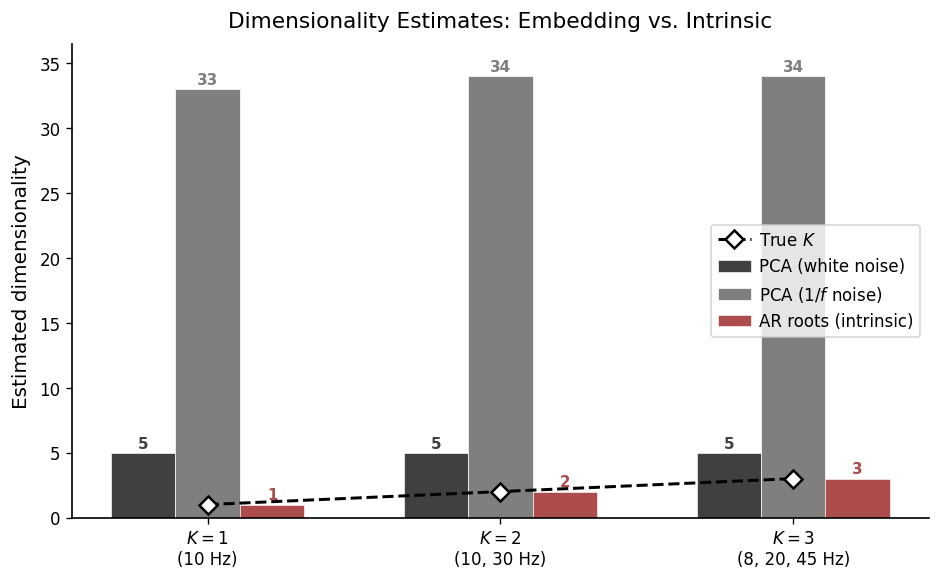

Signal                           True K   PCA (white)   PCA (1/f)   AR roots
───────────────────────────────────────────────────────────────────────────
  K = 1  (10 Hz)                      1             5          33          1
  K = 2  (10, 30 Hz)                  2             5          34          2
  K = 3  (8, 20, 45 Hz)               3             5          34          3


In [31]:
# ── Compute PCA dims with 1/f (pink) noise for all K ─────────
pca_dims_1f = []
for s in signals:
    noise = np.asarray(colored_noise(T, alpha=1.0, seed=7))
    noise = float(np.std(s["x"])) * 0.8 * noise
    x_noisy = s["x"] + noise
    H = hankel_matrix(x_noisy, L)
    d, _ = pca_dim_estimate(H, threshold=0.95)
    pca_dims_1f.append(d)

K_true = [len(s["freqs"]) for s in signals]

# ── Figure 8: Summary comparison ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(3)
w = 0.22

# Three grouped bars: black, darkred, dimgray
bars1 = ax.bar(x_pos - w, pca_dims_clean, w,
               label="PCA (white noise)", color=color_main, alpha=0.75,
               edgecolor="white", linewidth=0.5)
bars2 = ax.bar(x_pos, pca_dims_1f, w,
               label="PCA ($1/f$ noise)", color=c_gray, alpha=0.85,
               edgecolor="white", linewidth=0.5)
bars3 = ax.bar(x_pos + w, ar_modes_clean, w,
               label="AR roots (intrinsic)", color=c_accent, alpha=0.70,
               edgecolor="white", linewidth=0.5)

# True K dashed line with diamond markers
ax.plot(x_pos, K_true, color=color_main, ls="--", lw=1.8,
        marker="D", ms=8, zorder=5, label="True $K$",
        markerfacecolor="white", markeredgecolor=color_main,
        markeredgewidth=1.5)

# Value annotation on each bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.15,
                f"{int(h)}", ha="center", va="bottom",
                fontsize=9, fontweight="bold", color=bar.get_facecolor())

ax.set_xticks(x_pos)
ax.set_xticklabels(["$K=1$\n(10 Hz)",
                     "$K=2$\n(10, 30 Hz)",
                     "$K=3$\n(8, 20, 45 Hz)"],
                    fontsize=10)
ax.set_ylim(0, max(max(pca_dims_clean), max(pca_dims_1f),
                    max(ar_modes_clean)) + 2.5)
prettify(ax, title="Dimensionality Estimates: Embedding vs. Intrinsic",
         ylabel="Estimated dimensionality")
ax.legend(frameon=True, fontsize=10, loc="best", ncol=1,
          borderaxespad=0.5, handletextpad=0.5)

plt.tight_layout()
plt.show()

# ── Print summary table ──────────────────────────────────────
print(f"{'Signal':30s}  {'True K':>7s}  {'PCA (white)':>12s}  {'PCA (1/f)':>10s}  {'AR roots':>9s}")
print("─" * 75)
for s, d_w, d_f, d_ar in zip(signals, pca_dims_clean, pca_dims_1f, ar_modes_clean):
    K = len(s["freqs"])
    print(f"  {s['label']:28s}  {K:>7d}  {d_w:>12d}  {d_f:>10d}  {d_ar:>9d}")

## Key Takeaways

| | PCA Embedding Dimensionality | Intrinsic Dimensionality (Ours) |
|---|---|---|
| **What it captures** | Number of variance components | Number of oscillatory modes |
| **Mechanistic?** | ✗ — purely statistical | ✓ — identifies physical generators |
| **Robust to $1/f$ noise?** | ✗ — inflated by aperiodic background | ✓ — topology preserved |
| **Nonstationary signals?** | ✗ — conflates time epochs | ✓ — tracks evolving dynamics |
| **Output** | A number (*dim = N*) | K modes at specific frequencies |

**Bottom line:** Embedding dimensionality (PCA) answers *"how many components explain the variance?"* — a descriptive question. Intrinsic dimensionality via delay embedding and AR root analysis answers *"how many oscillatory generators drive the signal, and at what frequencies?"* — a **mechanistic** question that reveals the dynamical architecture of the system.

For real neural recordings where the goal is to understand the underlying circuit dynamics, intrinsic dimensionality provides the more informative and robust characterisation. See the [model tutorial](model.ipynb) for how DeepLagField recovers time-varying AR coefficients from real data to reconstruct these manifolds.